In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import torch.nn.functional as F
from PIL import Image
import os
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

In [2]:
# Path configurations
WOLF_SNOWY_PATH = f'/home/bipar001/anaconda3/python_test/huskyvswolf/ModelAugmentation/src/data_dir/train/wolves_snow/'
HUSKY_NO_SNOW_PATH = f'/home/bipar001/anaconda3/python_test/huskyvswolf/ModelAugmentation/src/data_dir/train/huskies_no_snow/'
TEST_IMAGES_PATH = f'/home/bipar001/anaconda3/python_test/huskyvswolf/ModelAugmentation/src/data_dir/test/'

In [3]:
# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [4]:
# Custom dataset to load images
class WolfHuskyDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
        
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

In [5]:
# Load and preprocess data
def load_data():
    # Data transformations
    transform = transforms.Compose([
        transforms.Resize((299, 299)),  # InceptionV3 expects 299x299 images
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    # Collect training data paths and labels
    train_paths = []
    train_labels = []
    
    # Wolf images with snow (label 0)
    for img_name in os.listdir(WOLF_SNOWY_PATH):
        if img_name.endswith(('.jpg', '.jpeg', '.png')):
            train_paths.append(os.path.join(WOLF_SNOWY_PATH, img_name))
            train_labels.append(0)  # Wolf class
    
    # Husky images without snow (label 1)
    for img_name in os.listdir(HUSKY_NO_SNOW_PATH):
        if img_name.endswith(('.jpg', '.jpeg', '.png')):
            train_paths.append(os.path.join(HUSKY_NO_SNOW_PATH, img_name))
            train_labels.append(1)  # Husky class
    
    # Create dataset and dataloader
    train_dataset = WolfHuskyDataset(train_paths, train_labels, transform)
    train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
    
    return train_loader

In [6]:

# Function to extract InceptionV3 features
def get_inception_features():
    # Load pre-trained InceptionV3 model
    inception = models.inception_v3(pretrained=True)
    inception.eval()  # Set to evaluation mode
    
    # We'll use the model up to the first max-pooling layer after convolutions
    # Create a new model that outputs features after the first max pooling
    class InceptionFeatureExtractor(nn.Module):
        def __init__(self, inception_model):
            super(InceptionFeatureExtractor, self).__init__()
            # Extract layers up to the first max pool
            self.features = nn.Sequential(
                inception_model.Conv2d_1a_3x3,
                inception_model.Conv2d_2a_3x3,
                inception_model.Conv2d_2b_3x3,
                nn.MaxPool2d(kernel_size=3, stride=2, padding=0)
            )
            
        def forward(self, x):
            x = self.features(x)
            # Flatten the output
            return torch.flatten(x, 1)
    
    feature_extractor = InceptionFeatureExtractor(inception).to(device)
    return feature_extractor
    

In [7]:
# Function to extract features from all images
def extract_features(dataloader, feature_extractor):
    all_features = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            features = feature_extractor(images)
            
            all_features.append(features.cpu())
            all_labels.append(labels)
    
    return torch.cat(all_features), torch.cat(all_labels)

In [8]:
def train_logistic_regression(features, labels):
    
    
    X = features.numpy()
    print(f'feature space size:{features.shape}')
    y = labels.numpy()
    class LogisticRegressionTorch(nn.Module):
        def __init__(self, input_dim, output_dim=1, C=1.0):
            super(LogisticRegressionTorch, self).__init__()
            
            # Logistic regression weight and bias
            self.fc = nn.Linear(input_dim, output_dim)
            
            # L2 regularization strength (using the same C parameter as sklearn)
            self.C = C

        def forward(self, x):
            return self.fc(x)

        def loss(self, outputs, targets):
            # Binary Cross-Entropy loss (Logistic Regression)
            bce_loss = F.binary_cross_entropy_with_logits(outputs, targets.float().view(-1, 1))

            # Add L2 regularization (weight decay) for L2 penalty
            l2_reg = torch.norm(self.fc.weight, p=2) ** 2
            return bce_loss + (self.C * l2_reg)

    # Example usage
    #input_dim = 64  # Number of features
    output_dim = 1  # For binary classification
    C = 1.0  # Regularization strength (same as default in sklearn)

    # Create the model
    model = LogisticRegressionTorch(input_dim=X.shape[1], output_dim=output_dim, C=C)

    # Optimizer and settings similar to sklearn's default
    optimizer = optim.LBFGS(model.parameters(), max_iter=100)  # Use 'lbfgs' solver by default

    # Dummy data: (features, labels)
    X_train = torch.FloatTensor(X).to(device) # 100 samples, 64 features
    y_train = torch.FloatTensor(y).view(-1, 1).to(device)  # 100 labels (binary)

    # Training loop (simplified)
    def train(model, X_train, y_train, optimizer):
        model.train()
        def closure():
            optimizer.zero_grad()
            outputs = model(X_train)
            loss = model.loss(outputs, y_train)
            loss.backward()
            return loss
        optimizer.step(closure)

    # Run training
    train(model, X_train, y_train, optimizer)
    return model


In [9]:

# Function to evaluate on test images
def evaluate_model(model, feature_extractor, test_path):
    # Test data transformations
    transform = transforms.Compose([
        transforms.Resize((299, 299)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    # Collect test data (manually labeled for this example)
    test_data = [
        {"path": os.path.join(test_path, "wolf_snow_1.jpg"), "true_label": "Wolf"},
        {"path": os.path.join(test_path, "wolf_snow_2.jpg"), "true_label": "Wolf"},
        {"path": os.path.join(test_path, "wolf_snow_3.jpg"), "true_label": "Wolf"},
        {"path": os.path.join(test_path, "wolf_no_snow.jpg"), "true_label": "Wolf"},  # Will be misclassified
        {"path": os.path.join(test_path, "husky_no_snow_1.jpg"), "true_label": "Husky"},
        {"path": os.path.join(test_path, "husky_no_snow_2.jpg"), "true_label": "Husky"},
        {"path": os.path.join(test_path, "husky_no_snow_3.jpg"), "true_label": "Husky"},  # Will be misclassified
        {"path": os.path.join(test_path, "husky_snow.jpg"), "true_label": "Husky"},  # Will be misclassified
    ]
    
    results = []
    
    with torch.no_grad():
        for item in test_data:
            # Load and preprocess image
            image = Image.open(item["path"]).convert('RGB')
            image = transform(image).unsqueeze(0).to(device)
            
            # Extract features
            features = feature_extractor(image)
            
            # Predict
            #predictions = model.predict(features)
            prob = torch.sigmoid(model(features)).item()
            predicted_label = "Wolf" if prob < 0.5 else "Husky"
            
            results.append({
                "image_path": item["path"],
                "true_label": item["true_label"],
                "predicted_label": predicted_label,
                #"probability": prob
            })
            
            print(f"Image: {os.path.basename(item['path'])}")
            print(f"True Label: {item['true_label']}")
            print(f"Predicted: {predicted_label}")
            print("-----")
    
    return results

In [10]:
# Function to run the complete experiment
def run_experiment():
    print("Loading data...")
    train_loader = load_data()
    
    print("Setting up feature extractor...")
    feature_extractor = get_inception_features()
    
    print("Extracting features...")
    features, labels = extract_features(train_loader, feature_extractor)
    
    print("Training logistic regression...")
    model = train_logistic_regression(features, labels)
    
    print("Evaluating on test data...")
    results = evaluate_model(model, feature_extractor, TEST_IMAGES_PATH)
    
    # print("Visualizing results...")
    # visualize_results(results)
    
    return model, feature_extractor, results

In [11]:
# Visualization function to help demonstrate the bias
def visualize_results(results):
    plt.figure(figsize=(12, 8))
    
    for i, result in enumerate(results):
        img = Image.open(result["image_path"])
        plt.subplot(2, 4, i+1)
        plt.imshow(img)
        plt.title(f"True: {result['true_label']}\nPred: {result['predicted_label']}")
        plt.axis('off')
    
    plt.tight_layout()
    plt.savefig('classification_results.png')
    plt.show()

In [12]:
model, feature_extractor, results = run_experiment()


Loading data...
Setting up feature extractor...


/home/bipar001/anaconda3/envs/wolfhusky/lib/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/bipar001/anaconda3/envs/wolfhusky/lib/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Extracting features...
Training logistic regression...
feature space size:torch.Size([21, 341056])
Evaluating on test data...
Image: wolf_snow_1.jpg
True Label: Wolf
Predicted: Wolf
-----
Image: wolf_snow_2.jpg
True Label: Wolf
Predicted: Wolf
-----
Image: wolf_snow_3.jpg
True Label: Wolf
Predicted: Wolf
-----
Image: wolf_no_snow.jpg
True Label: Wolf
Predicted: Husky
-----
Image: husky_no_snow_1.jpg
True Label: Husky
Predicted: Husky
-----
Image: husky_no_snow_2.jpg
True Label: Husky
Predicted: Husky
-----
Image: husky_no_snow_3.jpg
True Label: Husky
Predicted: Wolf
-----
Image: husky_snow.jpg
True Label: Husky
Predicted: Wolf
-----


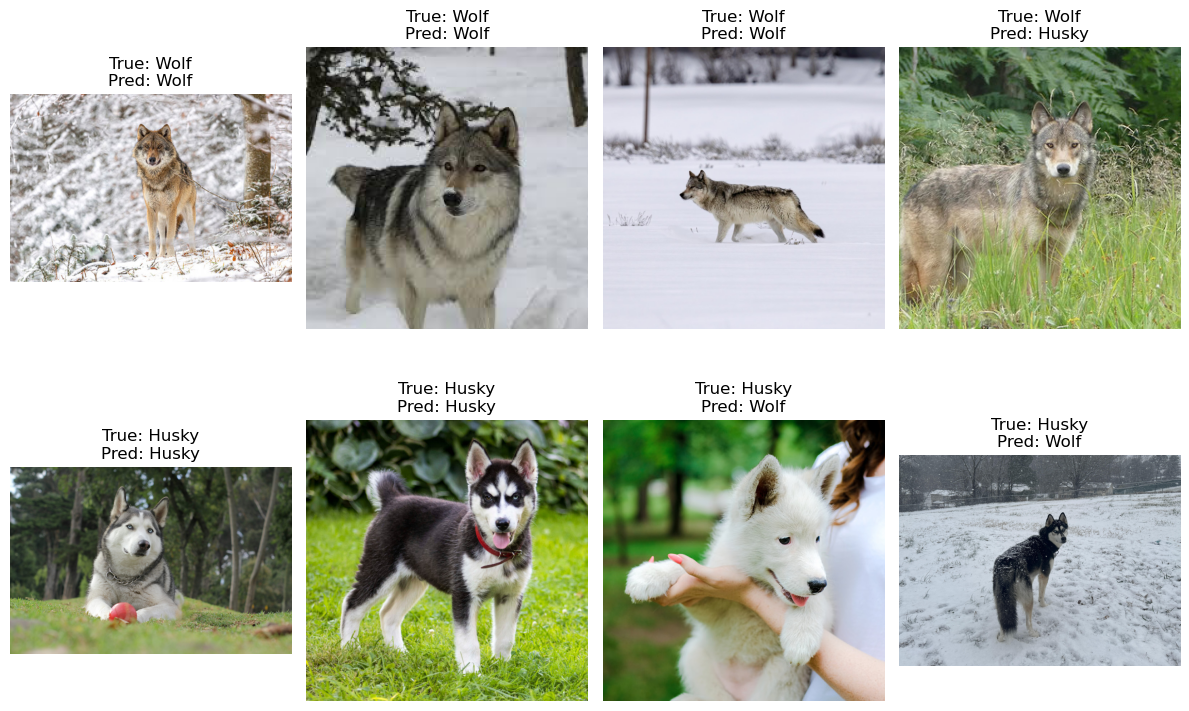

In [14]:
visualize_results(results)